# Notebook 05 - Experimento 1: Memoria temporal (con lag vs. sin lag)

## Objetivo
Cuantificar la contribución de la memoria temporal al rendimiento predictivo,
comparando modelos con y sin variables de *lag, rolling* y *deltas* frente a un
*baseline* de persistencia *naive*.

## Niveles de comparación

| Nivel | Descripción |
|---|---|
| Baseline naive | Persistencia: `power_pu(t) = power_pu(t-1)` |
| Con lag | Lags, rolling mean/std y deltas de potencia y radiación |
| Sin lag | Solo variables instantaneas y de calendario |

## Nota metodológica
Los *datasets* con y sin *lag* tienen distinto número de filas (los *lags* eliminan
las primeras filas por NaN). La evaluación final se realiza sobre el
**índice común** (intersección de filas disponibles en ambos escenarios)
para garantizar una comparación justa.

El entrenamiento se realiza sobre el conjunto completo incluyendo periodos
nocturnos. La evaluación se reporta tanto en el conjunto global como en
**horas de producción** (`power_pu > 0`) para evitar el sesgo nocturno.

## Definición de "sin lag"
El escenario sin *lag* excluye todas las variables de memoria temporal:
`power_pu_lag_*`, `radiation_lag_*`, *rolling features* y *deltas*.
El modelo solo dispone de variables instantaneas y de calendario.

## Diseño experimental
- **Train / Validacion:** Afrisol + E03
- **Test:** LECA1 (planta no vista durante el entrenamiento)


### 1. Configuración de rutas e importaciones


In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"

from src.data import add_nominal_power_and_target, split_train_val_test
from src.evaluation import (
    compute_metrics,
    compute_metrics_daylight,
    evaluate_all_models_daylight,
)
from src.features import FeatureConfig, build_features, get_feature_columns
from src.models import get_baseline_models

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga del dataset unificado


In [2]:
df_all = pd.read_csv(DATA_DIR / "df_all_unificado.csv", parse_dates=["timestamp"])

NOMINAL_POWER = {"E03": 12.4, "Afrisol": 12.0, "LECA1": 19.53}

df_all = df_all.drop(columns=["power_pu", "p_nominal_kw"], errors="ignore")
df_all = add_nominal_power_and_target(df_all, NOMINAL_POWER)

print(f"Shape: {df_all.shape}")
display(df_all.groupby("id_planta")["timestamp"].agg(["min", "max", "count"]))


Shape: (249285, 18)


,min,max,count
id_planta,,,
Afrisol,2022-01-01,2024-04-29 23:45:00,81111
E03,2022-01-01,2024-05-30 23:45:00,84087
LECA1,2022-01-01,2024-05-30 23:45:00,84087


### 3. Configuraciones de features: con lag y sin lag


In [3]:
# Escenario A: con memoria temporal
config_with_lag = FeatureConfig(
    lag_steps_power=(1, 2, 4),
    lag_steps_radiation=(1, 2),
    rolling_windows_power=(4, 8),
    rolling_windows_radiation=(4,),
    add_interactions=True,
    add_daylight_flag=True,
    drop_na_after_features=True,
    one_hot_encode_plant=False,
)

# Escenario B: sin memoria temporal
config_without_lag = FeatureConfig(
    lag_steps_power=(),
    lag_steps_radiation=(),
    rolling_windows_power=(),
    rolling_windows_radiation=(),
    add_interactions=True,
    add_daylight_flag=True,
    drop_na_after_features=True,
    one_hot_encode_plant=False,
)

print(f"Con lag  : lags_power={config_with_lag.lag_steps_power}, rolling={config_with_lag.rolling_windows_power}")
print(f"Sin lag  : lags_power={config_without_lag.lag_steps_power}, rolling={config_without_lag.rolling_windows_power}")


Con lag  : lags_power=(1, 2, 4), rolling=(4, 8)
Sin lag  : lags_power=(), rolling=()


### 4. Funcion auxiliar de preparación
Encapsula el *pipeline* de *feature engineering* y la partición *train/val/test*.
Las columnas de entrada se determinan sobre `train_df` para evitar
fuga de información desde val o test.


In [4]:
def prepare_dataset(df: pd.DataFrame, config: FeatureConfig) -> dict:
    """Aplica el pipeline de features y la partición temporal/espacial."""
    df_feat = build_features(df, config=config)
    df_feat = df_feat.drop(columns=["Mes"], errors="ignore")

    train_df, val_df, test_df = split_train_val_test(
        df_feat,
        train_plants=["E03", "Afrisol"],
        test_plant="LECA1",
        train_end="2023-12-31",
        val_start="2024-01-01",
        val_end="2024-02-29",
        test_start="2024-03-01",
        test_end="2024-05-30",
    )

    # Las columnas de entrada se determinan sobre train para evitar fuga
    feature_cols = get_feature_columns(train_df)

    return {
        "df_feat":      df_feat,
        "train_df":     train_df,
        "val_df":       val_df,
        "test_df":      test_df,
        "feature_cols": feature_cols,
        "X_train": train_df[feature_cols], "y_train": train_df["power_pu"],
        "X_val":   val_df[feature_cols],   "y_val":   val_df["power_pu"],
        "X_test":  test_df[feature_cols],  "y_test":  test_df["power_pu"],
    }


### 5. Preparación de los dos escenarios


In [5]:
data_with_lag    = prepare_dataset(df_all, config_with_lag)
data_without_lag = prepare_dataset(df_all, config_without_lag)

print(f"Con lag  : {len(data_with_lag['feature_cols'])} features | "
      f"train={data_with_lag['X_train'].shape[0]:,} | "
      f"test={data_with_lag['X_test'].shape[0]:,}")
print(f"Sin lag  : {len(data_without_lag['feature_cols'])} features | "
      f"train={data_without_lag['X_train'].shape[0]:,} | "
      f"test={data_without_lag['X_test'].shape[0]:,}")

# Indice comun para la evaluacion final comparativa
common_index = data_with_lag["test_df"].index.intersection(
    data_without_lag["test_df"].index
)
print(f"\nFilas comunes para evaluación comparativa: {len(common_index):,}")


2026-05-27 10:10:55 - INFO - Split: train=138986 | val=11330 | test=8639
2026-05-27 10:10:58 - INFO - Split: train=138994 | val=11330 | test=8639


Con lag  : 32 features | train=138,986 | test=8,639
Sin lag  : 19 features | train=138,994 | test=8,639

Filas comunes para evaluación comparativa: 8,627


### 6. Baseline naive (persistencia)
El modelo de persistencia predice `power_pu(t) = power_pu(t-1)`.
Sirve como referencia mínima.


In [6]:
naive_test = data_with_lag["test_df"].loc[common_index].copy()
naive_test["y_pred_naive"] = naive_test["power_pu_lag_1"]
naive_test = naive_test.dropna(subset=["y_pred_naive"])

metrics_naive_global = compute_metrics(
    naive_test["power_pu"], naive_test["y_pred_naive"]
)
mask_day_naive = naive_test["power_pu"] > 0
metrics_naive_day = compute_metrics(
    naive_test.loc[mask_day_naive, "power_pu"],
    naive_test.loc[mask_day_naive, "y_pred_naive"],
)

df_naive = pd.DataFrame([
    {"model": "naive", "type": "baseline", "scope": "global",   **metrics_naive_global},
    {"model": "naive", "type": "baseline", "scope": "daylight", **metrics_naive_day},
])
display(df_naive.round(6))


,model,type,scope,MAE,RMSE,R2
0,naive,baseline,global,0.034270,0.076757,0.919655
1,naive,baseline,daylight,0.061248,0.102645,0.869261


### 7. Función de entrenamiento y evaluación
El entrenamiento usa el conjunto completo de *train* (incluyendo noche).
Las métricas se calculan sobre `X_test` completo (global) y también
filtradas a horas de producción (*daylight*), igual que en el original.


In [7]:
def train_and_compare_base_models(data_bundle: dict, scenario_name: str) -> tuple:
    """Entrena todos los modelos y devuelve métricas y modelos entrenados."""
    models  = get_baseline_models(random_state=42)
    results = []
    trained = {}

    X_train, y_train = data_bundle["X_train"], data_bundle["y_train"]
    X_val,   y_val   = data_bundle["X_val"],   data_bundle["y_val"]
    X_test,  y_test  = data_bundle["X_test"],  data_bundle["y_test"]

    for name, model in models.items():
        print(f"  Entrenando {name} [{scenario_name}]...")
        model.fit(X_train, y_train)
        trained[name] = model

        pred_val  = model.predict(X_val)
        pred_test = model.predict(X_test)

        m_val_global  = compute_metrics(y_val,  pred_val)
        m_test_global = compute_metrics(y_test, pred_test)

        mask_val_day  = y_val  > 0
        mask_test_day = y_test > 0

        m_val_day  = compute_metrics(y_val[mask_val_day],   pred_val[mask_val_day])
        m_test_day = compute_metrics(y_test[mask_test_day], pred_test[mask_test_day])

        results.append({
            "scenario":         scenario_name,
            "model":            name,
            "MAE_val_global":   m_val_global["MAE"],
            "RMSE_val_global":  m_val_global["RMSE"],
            "R2_val_global":    m_val_global["R2"],
            "MAE_test_global":  m_test_global["MAE"],
            "RMSE_test_global": m_test_global["RMSE"],
            "R2_test_global":   m_test_global["R2"],
            "MAE_val_day":      m_val_day["MAE"],
            "RMSE_val_day":     m_val_day["RMSE"],
            "R2_val_day":       m_val_day["R2"],
            "MAE_test_day":     m_test_day["MAE"],
            "RMSE_test_day":    m_test_day["RMSE"],
            "R2_test_day":      m_test_day["R2"],
        })

    df_res = pd.DataFrame(results).sort_values("RMSE_test_day").reset_index(drop=True)
    return df_res, trained


#### Escenario A: con lag


In [8]:
df_with_lag, trained_with_lag = train_and_compare_base_models(
    data_with_lag, "with_lag"
)
display(df_with_lag.round(6))


  Entrenando Ridge [with_lag]...
  Entrenando Random Forest [with_lag]...
  Entrenando ExtraTrees [with_lag]...
  Entrenando XGBoost [with_lag]...
  Entrenando LightGBM [with_lag]...
  Entrenando CatBoost [with_lag]...
  Entrenando MLP [with_lag]...


,scenario,model,MAE_val_global,RMSE_val_global,R2_val_global,MAE_test_global,RMSE_test_global,R2_test_global,MAE_val_day,RMSE_val_day,R2_val_day,MAE_test_day,RMSE_test_day,R2_test_day
0,with_lag,MLP,0.008035,0.022560,0.984319,0.016774,0.043844,0.973767,0.017545,0.032297,0.977338,0.028991,0.058411,0.957663
1,with_lag,Ridge,0.011052,0.025919,0.979302,0.018321,0.044516,0.972956,0.021844,0.038550,0.967711,0.030291,0.058572,0.957429
2,with_lag,XGBoost,0.008766,0.024790,0.981066,0.024667,0.051506,0.963797,0.020994,0.036431,0.971163,0.043775,0.068757,0.941338
3,with_lag,LightGBM,0.009011,0.024270,0.981852,0.025583,0.052452,0.962454,0.021661,0.035775,0.972194,0.045547,0.070149,0.938938
4,with_lag,CatBoost,0.010365,0.025528,0.979921,0.026127,0.053140,0.961463,0.024313,0.038026,0.968584,0.046393,0.071065,0.937332
5,with_lag,Random Forest,0.008348,0.025889,0.979349,0.024331,0.053986,0.960226,0.020573,0.038545,0.967721,0.043000,0.071497,0.936568
6,with_lag,ExtraTrees,0.008782,0.025752,0.979567,0.028032,0.058454,0.953371,0.021363,0.038115,0.968437,0.049643,0.077856,0.924783


#### Escenario B: sin lag


In [9]:
df_without_lag, trained_without_lag = train_and_compare_base_models(
    data_without_lag, "without_lag"
)
display(df_without_lag.round(6))


  Entrenando Ridge [without_lag]...
  Entrenando Random Forest [without_lag]...
  Entrenando ExtraTrees [without_lag]...
  Entrenando XGBoost [without_lag]...
  Entrenando LightGBM [without_lag]...
  Entrenando CatBoost [without_lag]...
  Entrenando MLP [without_lag]...


,scenario,model,MAE_val_global,RMSE_val_global,R2_val_global,MAE_test_global,RMSE_test_global,R2_test_global,MAE_val_day,RMSE_val_day,R2_val_day,MAE_test_day,RMSE_test_day,R2_test_day
0,without_lag,Ridge,0.039322,0.055239,0.905987,0.054470,0.105577,0.847885,0.050992,0.070299,0.892629,0.077087,0.132509,0.782120
1,without_lag,ExtraTrees,0.026888,0.067163,0.861021,0.051100,0.107051,0.843607,0.063616,0.099846,0.783401,0.088627,0.138093,0.763367
2,without_lag,Random Forest,0.027790,0.068497,0.855445,0.051424,0.107209,0.843144,0.065363,0.101544,0.775972,0.089194,0.138271,0.762758
3,without_lag,XGBoost,0.028898,0.068005,0.857512,0.051528,0.107440,0.842468,0.067329,0.101334,0.776899,0.089258,0.138704,0.761271
4,without_lag,CatBoost,0.028601,0.063397,0.876169,0.051621,0.107405,0.842571,0.064143,0.093902,0.808425,0.089205,0.138824,0.760858
5,without_lag,LightGBM,0.027910,0.068874,0.853848,0.051767,0.107951,0.840966,0.065484,0.102745,0.770640,0.089815,0.139515,0.758470
6,without_lag,MLP,0.034222,0.084982,0.777489,0.052691,0.107955,0.840954,0.081974,0.130309,0.631069,0.091440,0.139749,0.757661


### 8. Tabla comparativa final sobre índice común
Para comparar con/sin *lag* en igualdad de condiciones se reevaluan los
modelos ya entrenados sobre el índice común del test.


In [10]:
# ============================================================
# 8. Tabla comparativa final sobre índice común
# ============================================================

# ------------------------------------------------------------
# 1. Construcción correcta del índice común
# ------------------------------------------------------------
# Se utiliza únicamente el conjunto de índices compartidos
# entre ambos escenarios (with_lag y without_lag)
# para garantizar una comparación justa.

common_index = (
    data_with_lag["X_test"].index
    .intersection(data_without_lag["X_test"].index)
    .intersection(data_with_lag["y_test"].index)
    .intersection(data_without_lag["y_test"].index)
)

print(f"Número de muestras comunes: {len(common_index)}")


# ------------------------------------------------------------
# 2. Conjuntos comunes WITH LAG
# ------------------------------------------------------------

X_common_lag = data_with_lag["X_test"].loc[common_index]
y_common_lag = data_with_lag["y_test"].loc[common_index]


# ------------------------------------------------------------
# 3. Conjuntos comunes WITHOUT LAG
# ------------------------------------------------------------

X_common_nolag = data_without_lag["X_test"].loc[common_index]
y_common_nolag = data_without_lag["y_test"].loc[common_index]


# ------------------------------------------------------------
# 4. Comprobación de alineación
# ------------------------------------------------------------

print("\nVerificación de índices:")

print(
    "with_lag:",
    X_common_lag.index.equals(y_common_lag.index)
)

print(
    "without_lag:",
    X_common_nolag.index.equals(y_common_nolag.index)
)


# ============================================================
# Función de evaluación global
# ============================================================

def evaluate_all_global(trained_models: dict, X_test, y_test):

    rows = []

    for name, model in trained_models.items():

        y_pred = model.predict(X_test)

        metrics = compute_metrics(y_test, y_pred)

        metrics["model"] = name

        rows.append(metrics)

    return (
        pd.DataFrame(rows)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )


# ============================================================
# 5. Evaluación GLOBAL
# ============================================================

df_g_lag = evaluate_all_global(
    trained_with_lag,
    X_common_lag,
    y_common_lag
)

df_g_nolag = evaluate_all_global(
    trained_without_lag,
    X_common_nolag,
    y_common_nolag
)

df_g_naive = pd.DataFrame([
    {
        "model": "naive",
        **metrics_naive_global
    }
])

df_g_lag["type"] = "with_lag"
df_g_nolag["type"] = "without_lag"
df_g_naive["type"] = "baseline"


# ============================================================
# 6. Evaluación DAYLIGHT
# ============================================================

df_d_lag = evaluate_all_models_daylight(
    trained_with_lag,
    X_common_lag,
    y_common_lag
)

df_d_nolag = evaluate_all_models_daylight(
    trained_without_lag,
    X_common_nolag,
    y_common_nolag
)

df_d_naive = pd.DataFrame([
    {
        "model": "naive",
        **metrics_naive_day
    }
])

df_d_lag["type"] = "with_lag"
df_d_nolag["type"] = "without_lag"
df_d_naive["type"] = "baseline"


# ============================================================
# 7. Unión de resultados
# ============================================================

df_global = pd.concat(
    [
        df_g_naive,
        df_g_lag,
        df_g_nolag
    ],
    ignore_index=True
)

df_daylight = pd.concat(
    [
        df_d_naive,
        df_d_lag,
        df_d_nolag
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Renombrado de columnas
# ------------------------------------------------------------

df_global = df_global.rename(
    columns={
        "RMSE": "RMSE_global",
        "MAE": "MAE_global",
        "R2": "R2_global"
    }
)

df_daylight = df_daylight.rename(
    columns={
        "RMSE": "RMSE_day",
        "MAE": "MAE_day",
        "R2": "R2_day"
    }
)


# ------------------------------------------------------------
# Merge final
# ------------------------------------------------------------

df_compare = df_global.merge(
    df_daylight,
    on=["model", "type"]
)


# ------------------------------------------------------------
# Orden por RMSE daylight
# ------------------------------------------------------------

df_compare = (
    df_compare
    .sort_values("RMSE_day")
    .reset_index(drop=True)
)


# ============================================================
# 8. Mejora respecto al baseline naive
# ============================================================

rmse_naive_day = df_compare.loc[
    df_compare["model"] == "naive",
    "RMSE_day"
].values[0]

df_compare["mejora_vs_naive"] = (
    rmse_naive_day - df_compare["RMSE_day"]
)


# ============================================================
# 9. Mostrar resultados
# ============================================================

display(df_compare.round(6))

Número de muestras comunes: 8627

Verificación de índices:
with_lag: True
without_lag: True


,model,MAE_global,RMSE_global,R2_global,type,MAE_day,RMSE_day,R2_day,mejora_vs_naive
0,MLP,0.016797,0.043874,0.973749,with_lag,0.028991,0.058411,0.957663,0.044234
1,Ridge,0.018344,0.044547,0.972938,with_lag,0.030291,0.058572,0.957429,0.044073
2,XGBoost,0.024701,0.051542,0.963772,with_lag,0.043775,0.068757,0.941338,0.033889
3,LightGBM,0.025619,0.052489,0.962428,with_lag,0.045547,0.070149,0.938938,0.032496
4,CatBoost,0.026164,0.053177,0.961437,with_lag,0.046393,0.071065,0.937332,0.031580
5,Random Forest,0.024365,0.054023,0.960199,with_lag,0.043000,0.071497,0.936568,0.031148
6,ExtraTrees,0.028071,0.058494,0.953339,with_lag,0.049643,0.077856,0.924783,0.024789
7,naive,0.034270,0.076757,0.919655,baseline,0.061248,0.102645,0.869261,0.000000
8,Ridge,0.054496,0.105641,0.847808,without_lag,0.077103,0.132534,0.782002,-0.029889
9,ExtraTrees,0.051170,0.107125,0.843501,without_lag,0.088662,0.138122,0.763232,-0.035477


### 9. Gráfico comparativo: RMSE en horas de producción
La linea discontinua marca el RMSE del *baseline naive*. Los modelos
por encima de ella no superan la persistencia simple.


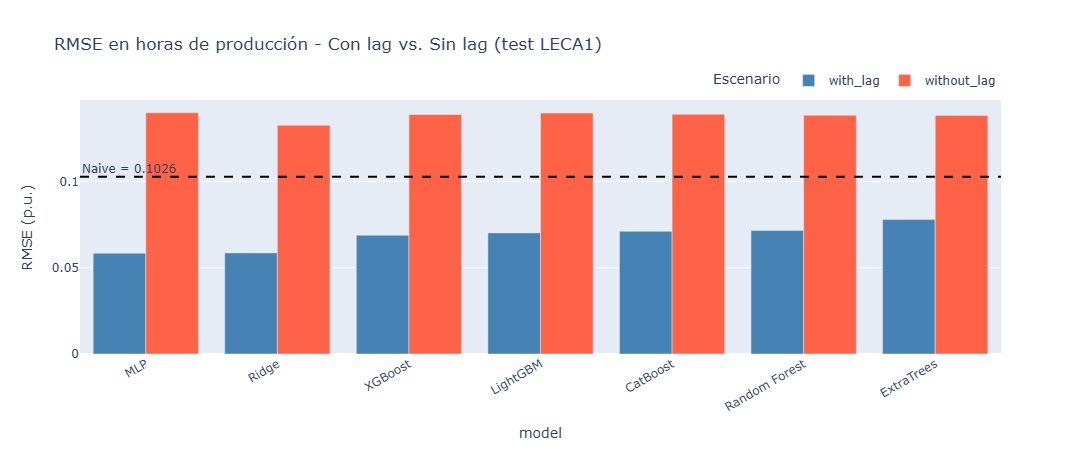

In [13]:
df_plot = df_compare[df_compare["type"] != "baseline"].sort_values("RMSE_day")

fig = px.bar(
    df_plot,
    x="model", y="RMSE_day", color="type", barmode="group",
    title="RMSE en horas de producción - Con lag vs. Sin lag (test LECA1)",
    labels={"RMSE_day": "RMSE (p.u.)", "type": "Escenario"},
    color_discrete_map={"with_lag": "steelblue", "without_lag": "tomato"},
)
fig.add_hline(
    y=rmse_naive_day,
    line_dash="dash", line_color="black",
    annotation_text=f"Naive = {rmse_naive_day:.4f}",
    annotation_position="top left",

)
fig.update_layout(xaxis_tickangle=-30, height=450,
        legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
                 )
fig.show()


### 10. Análisis del error por hora del día
MAE horario de los mejores modelos de cada escenario
restringido a horas de producción.


Mejor modelo con lag:  MLP
Mejor modelo sin lag:  Ridge


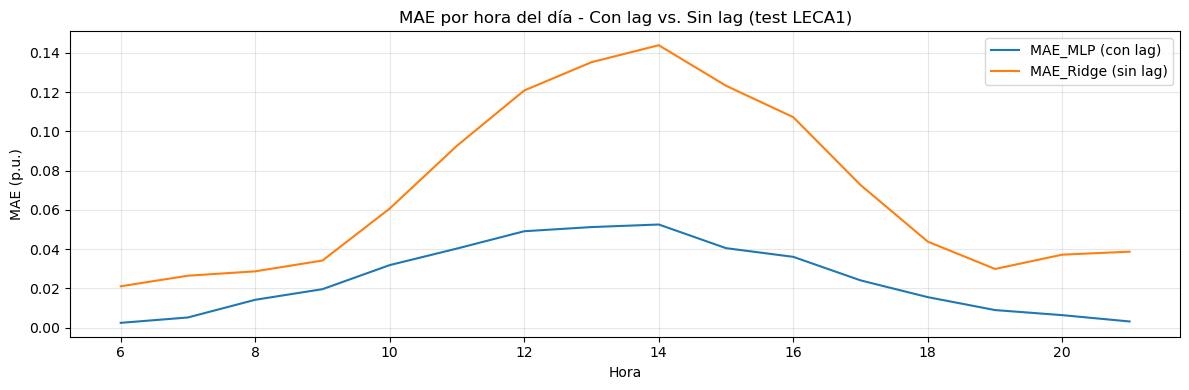

,MAE_MLP (con lag),MAE_Ridge (sin lag)
hour,,
6,0.002494,0.021112
7,0.005230,0.026492
8,0.014233,0.028715
9,0.019634,0.034224
10,0.031892,0.060700
11,0.040316,0.092673
12,0.049130,0.120792
13,0.051250,0.135187
14,0.052552,0.143828


In [14]:
best_lag    = df_d_lag.sort_values("RMSE").iloc[0]["model"]
best_no_lag = df_d_nolag.sort_values("RMSE").iloc[0]["model"]
print(f"Mejor modelo con lag:  {best_lag}")
print(f"Mejor modelo sin lag:  {best_no_lag}")

test_lag    = data_with_lag["test_df"].loc[common_index].copy()
test_no_lag = data_without_lag["test_df"].loc[common_index].copy()

test_lag["y_pred"]    = trained_with_lag[best_lag].predict(X_common_lag)
test_no_lag["y_pred"] = trained_without_lag[best_no_lag].predict(X_common_nolag)

test_lag["abs_error"]    = (test_lag["power_pu"] - test_lag["y_pred"]).abs()
test_no_lag["abs_error"] = (test_no_lag["power_pu"] - test_no_lag["y_pred"]).abs()

if "hour" not in test_lag.columns:
    test_lag["hour"] = test_lag["timestamp"].dt.hour
if "hour" not in test_no_lag.columns:
    test_no_lag["hour"] = test_no_lag["timestamp"].dt.hour

hourly = pd.concat([
    test_lag[test_lag["power_pu"] > 0].groupby("hour")["abs_error"].mean()
        .rename(f"MAE_{best_lag} (con lag)"),
    test_no_lag[test_no_lag["power_pu"] > 0].groupby("hour")["abs_error"].mean()
        .rename(f"MAE_{best_no_lag} (sin lag)"),
], axis=1)

hourly.plot(figsize=(12, 4), title="MAE por hora del día - Con lag vs. Sin lag (test LECA1)")
plt.xlabel("Hora")
plt.ylabel("MAE (p.u.)")
plt.grid(alpha=0.3)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "mae_por_hora_lag_vs_nolag.png", dpi=150)
plt.show()
display(hourly.round(6))


### 11. Análisis del error por nivel de irradiancia


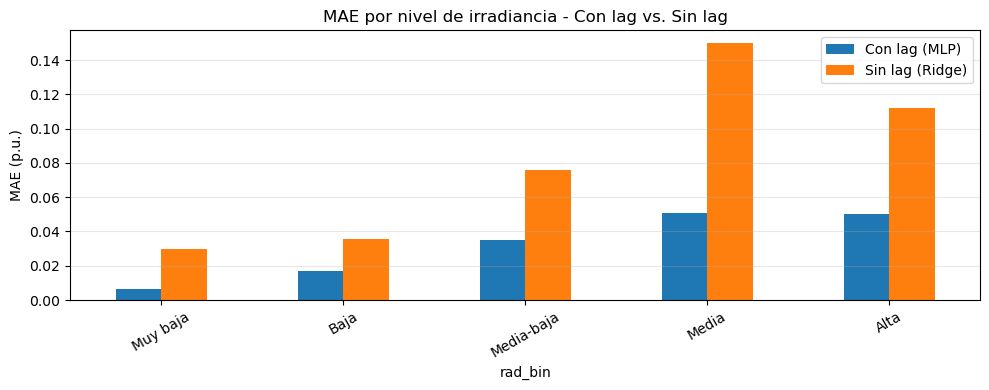

,Con lag (MLP),Sin lag (Ridge)
rad_bin,,
Muy baja,0.006686,0.029633
Baja,0.016956,0.035543
Media-baja,0.035113,0.075987
Media,0.050748,0.149898
Alta,0.050028,0.112317


In [15]:
bins   = [0, 100, 300, 600, 1000, 2000]
labels = ["Muy baja", "Baja", "Media-baja", "Media", "Alta"]

test_lag_rad    = data_with_lag["test_df"].loc[common_index].copy()
test_no_lag_rad = data_without_lag["test_df"].loc[common_index].copy()

test_lag_rad["y_pred"]    = trained_with_lag[best_lag].predict(X_common_lag)
test_no_lag_rad["y_pred"] = trained_without_lag[best_no_lag].predict(X_common_nolag)

test_lag_rad["abs_error"]    = (test_lag_rad["power_pu"] - test_lag_rad["y_pred"]).abs()
test_no_lag_rad["abs_error"] = (test_no_lag_rad["power_pu"] - test_no_lag_rad["y_pred"]).abs()

test_lag_rad["rad_bin"]    = pd.cut(test_lag_rad["radiation"],    bins=bins, labels=labels)
test_no_lag_rad["rad_bin"] = pd.cut(test_no_lag_rad["radiation"], bins=bins, labels=labels)

# Solo horas de produccion
test_lag_rad    = test_lag_rad[test_lag_rad["power_pu"] > 0]
test_no_lag_rad = test_no_lag_rad[test_no_lag_rad["power_pu"] > 0]

df_rad = pd.DataFrame({
    f"Con lag ({best_lag})":    test_lag_rad.groupby("rad_bin", observed=True)["abs_error"].mean(),
    f"Sin lag ({best_no_lag})": test_no_lag_rad.groupby("rad_bin", observed=True)["abs_error"].mean(),
})

df_rad.plot(kind="bar", figsize=(10, 4),
            title="MAE por nivel de irradiancia - Con lag vs. Sin lag")
plt.xticks(rotation=30)
plt.ylabel("MAE (p.u.)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mae_por_irradiancia_lag_vs_nolag.png", dpi=150)
plt.show()
display(df_rad.round(6))


### 12. Guardado de modelos, metadatos y resultados


In [28]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Modelos
joblib.dump(
    trained_with_lag[best_lag],
    MODELS_DIR / f"best_with_lag_{best_lag.replace(' ', '_')}.joblib",
)
joblib.dump(
    trained_without_lag[best_no_lag],
    MODELS_DIR / f"best_without_lag_{best_no_lag.replace(' ', '_')}.joblib",
)

# Metadatos
metadata = {
    "best_with_lag":        best_lag,
    "best_without_lag":     best_no_lag,
    "features_with_lag":    data_with_lag["feature_cols"],
    "features_without_lag": data_without_lag["feature_cols"],
}
with open(MODELS_DIR / "best_models_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# Predicciones alineadas con common_index para analisis posteriores
for scenario, test_df_src, X_common, model_name, trained_dict in [
    ("with_lag",    data_with_lag["test_df"],    X_common_lag,   best_lag,    trained_with_lag),
    ("without_lag", data_without_lag["test_df"], X_common_nolag, best_no_lag, trained_without_lag),
]:
    df_seg = test_df_src.loc[common_index].copy()
    df_seg["y_true"]     = df_seg["power_pu"]
    df_seg["y_pred"]     = trained_dict[model_name].predict(X_common)
    df_seg["error"]      = df_seg["y_pred"] - df_seg["y_true"]
    df_seg["abs_error"]  = df_seg["error"].abs()
    df_seg["model_name"] = model_name
    df_seg["scenario"]   = scenario
    df_seg.to_csv(RESULTS_DIR / f"segmentation_base_{scenario}.csv", index=False)

# Tabla comparativa
df_compare.to_csv(RESULTS_DIR / "exp1_lag_vs_nolag.csv", index=False)

print(f"Mejor modelo con lag:  {best_lag}")
print(f"Mejor modelo sin lag:  {best_no_lag}")
print("Modelos, metadatos y resultados guardados.")


Mejor modelo con lag:  MLP
Mejor modelo sin lag:  Ridge
Modelos, metadatos y resultados guardados.


## Conclusiones del Experimento 1

1. Los *lags* mejoran de forma consistente todos los modelos: el RMSE_day
   se reduce significativamente respecto al escenario sin *lag*.
2. Sin *lag*, los modelos no superan al *baseline naive* de persistencia,
   lo que confirma que la memoria temporal aporta valor real.
3. La mejora es especialmente pronunciada en irradiancia media-alta
   (300-1000 W/m2), donde la dinámica del sistema es más compleja.
4. En las horas centrales del día (pico de producción) el error es
   máximo en ambos escenarios, pero la brecha entre con/sin *lag* es mayor.
5. En transiciones rápidas de irradiancia los *lags* ayudan a suavizar
   pero no a anticipar cambios bruscos.

**Archivos de salida:**
- `data/models/best_with_lag_*.joblib`
- `data/models/best_without_lag_*.joblib`
- `data/models/best_models_metadata.json`
- `data/results/exp1_lag_vs_nolag.csv`
- `data/results/segmentation_base_with_lag.csv`
- `data/results/segmentation_base_without_lag.csv`

**Siguiente paso:** Experimento 2 - segmentacion de errores por contexto operativo.
